# 02 - Non-Personalized Baselines

In [2]:
import sys
import os
os.chdir('/Users/mariaparis/Downloads/recommender_assignment_placeholders')
sys.path.insert(0, '/Users/mariaparis/Downloads/recommender_assignment_placeholders')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_loading import load_ratings, load_items, train_test_split_ratings
from src.baselines import MostPopularRecommender, HighestAverageRatingRecommender, RandomRecommender

In [4]:
ratings = load_ratings()
items   = load_items()
train, test = train_test_split_ratings(ratings, test_size=0.2)
title_map = items.set_index(config.ITEM_COL)[config.TITLE_COL].to_dict()

## 1. Random recommender


In [5]:
random_rec = RandomRecommender(random_state=42)
random_rec.fit(train)

recs = random_rec.recommend(user_id=1, ratings_train=train, n=10)
pd.DataFrame({'Rank': range(1, 11), 'Title': [title_map.get(r, r) for r in recs]})

,Rank,Title
0,1,Amityville 1992: It's About Time (1992)
1,2,Tickling Giants (2017)
2,3,National Treasure: Book of Secrets (2007)
3,4,I'm Gonna Git You Sucka (1988)
4,5,"Beach, The (2000)"
5,6,For the Birds (2000)
6,7,Patch Adams (1998)
7,8,Bill Burr: Why Do I Do This? (2008)
8,9,Lost in the Sun (2015)
9,10,Hit by Lightning (2014)


## 2. Most Popular recommender

Recommends the items with the highest number of ratings across all users. No personalisation, every user gets the same list minus what they have already seen.

**Design choice:** we rank by interaction count, not average rating. A movie with 300 ratings at 3.8 is more reliably popular than one with 5 ratings at 5.0.

In [6]:
pop_rec = MostPopularRecommender()
pop_rec.fit(train)

recs = pop_rec.recommend(user_id=1, ratings_train=train, n=10)
pd.DataFrame({'Rank': range(1, 11), 'Title': [title_map.get(r, r) for r in recs]})

,Rank,Title
0,1,"Shawshank Redemption, The (1994)"
1,2,Terminator 2: Judgment Day (1991)
2,3,Raiders of the Lost Ark (Indiana Jones and the...
3,4,"Lord of the Rings: The Fellowship of the Ring,..."
4,5,Apollo 13 (1995)
5,6,"Godfather, The (1972)"
6,7,Aladdin (1992)
7,8,True Lies (1994)
8,9,"Sixth Sense, The (1999)"
9,10,Shrek (2001)


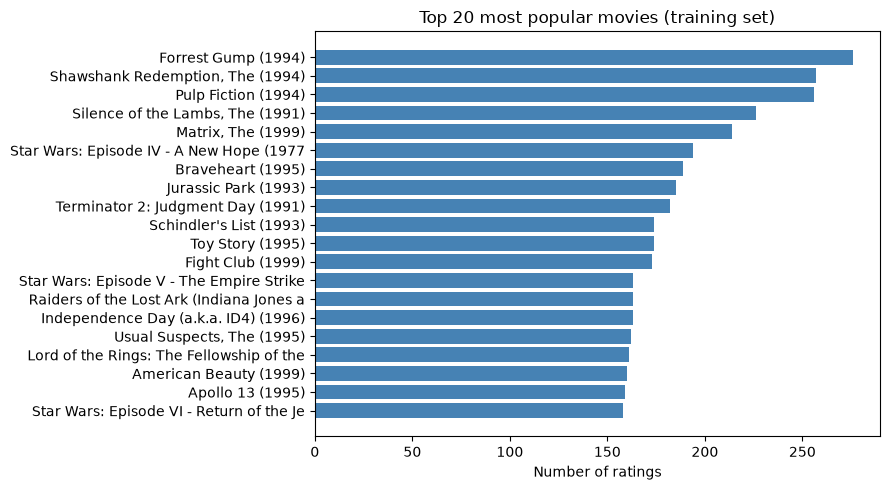

In [7]:
# Visualise the top-20 most popular movies
item_counts = (
    train.groupby(config.ITEM_COL).size()
    .reset_index(name='count')
    .merge(items[[config.ITEM_COL, config.TITLE_COL]], on=config.ITEM_COL)
    .sort_values('count', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(item_counts[config.TITLE_COL].str[:40], item_counts['count'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Number of ratings')
ax.set_title('Top 20 most popular movies (training set)')
plt.tight_layout()
plt.savefig('results/figures/most_popular.png', dpi=150)
plt.show()

## 3. Highest Average Rating recommender

Recommends items with the highest average rating. We require a minimum of 20 ratings before including a movie in the ranking. Without this threshold, obscure movies with a single 5-star rating would dominate the list — which is not useful.

**Design choice:** `min_ratings=20` is a deliberate decision that balances statistical reliability with catalog coverage.

In [8]:
avg_rec = HighestAverageRatingRecommender(min_ratings=20)
avg_rec.fit(train)

recs = avg_rec.recommend(user_id=1, ratings_train=train, n=10)
pd.DataFrame({'Rank': range(1, 11), 'Title': [title_map.get(r, r) for r in recs]})

,Rank,Title
0,1,"Shawshank Redemption, The (1994)"
1,2,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
2,3,"Philadelphia Story, The (1940)"
3,4,To Catch a Thief (1955)
4,5,Toy Story 3 (2010)
5,6,Cool Hand Luke (1967)
6,7,Casablanca (1942)
7,8,Harold and Maude (1971)
8,9,"Godfather, The (1972)"
9,10,"Manchurian Candidate, The (1962)"


## 4. Comparing baselines for three users

Since baselines are non-personalised, the only difference between users is which items they have already seen (those are excluded). We show this for three users.

In [9]:
sample_users = [1, 50, 100]

for uid in sample_users:
    print(f"\n--- User {uid} ---")
    for name, model in [("Most Popular", pop_rec), ("Highest Rated", avg_rec)]:
        recs = model.recommend(uid, train, n=5)
        titles = [title_map.get(r, r) for r in recs]
        print(f"  {name}: {', '.join(titles[:3])}...")


--- User 1 ---
  Most Popular: Shawshank Redemption, The (1994), Terminator 2: Judgment Day (1991), Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)...
  Highest Rated: Shawshank Redemption, The (1994), Sunset Blvd. (a.k.a. Sunset Boulevard) (1950), Philadelphia Story, The (1940)...

--- User 50 ---
  Most Popular: Shawshank Redemption, The (1994), Pulp Fiction (1994), Star Wars: Episode IV - A New Hope (1977)...
  Highest Rated: Shawshank Redemption, The (1994), Sunset Blvd. (a.k.a. Sunset Boulevard) (1950), Philadelphia Story, The (1940)...

--- User 100 ---
  Most Popular: Shawshank Redemption, The (1994), Silence of the Lambs, The (1991), Matrix, The (1999)...
  Highest Rated: Shawshank Redemption, The (1994), Sunset Blvd. (a.k.a. Sunset Boulevard) (1950), Philadelphia Story, The (1940)...


## 5. Key observations

- **Most Popular** tends to surface well-known blockbusters like Forrest Gump and Pulp Fiction. These are safe bets because they are broadly liked, but they offer no personalisation.
- **Highest Rated** (with minimum ratings) surfaces critically acclaimed classics like The Shawshank Redemption. The minimum rating threshold is crucial: without it the list would be filled with niche films that happen to have one or two perfect scores.
- **Random** is the true lower bound. A model that beats random is the minimum bar for any recommender to be considered useful.

These baselines will appear in the final evaluation table alongside the personalised methods, giving context to how much value the more complex models add.